# Análise Exploratória de Dados (EDA)

O objetivo desta Análise Exploratória é compreender a estrutura, os padrões, os relacionamentos e possíveis anomalias presentes nos dados. Esse entendimento servirá de base para a etapa de feature engineering e para a construção da Analytical Base Table (ABT), que será utilizada no treinamento dos modelos de machine learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import yaml


def find_project_root(marker="DataPipeline/config.yml"):
    p = Path.cwd().resolve()

    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        "Raiz do projeto não encontrada (DataPipeline/config.yml ausente)."
    )


# Carrega a configuração do projeto
PROJECT_ROOT = find_project_root()

with open(PROJECT_ROOT / "DataPipeline" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Diretório da camada clean
CLEAN_DIR = PROJECT_ROOT / cfg["paths"]["clean_dir"]

# Carrega as tabelas sanitizadas
clean_files = cfg["data"]["clean_files"]

df_application = pd.read_parquet(CLEAN_DIR / clean_files["application"])
df_bureau = pd.read_parquet(CLEAN_DIR / clean_files["bureau"])
df_previous_application = pd.read_parquet(
    CLEAN_DIR / clean_files["previous_application"]
)

In [3]:
def resumo_inicial(df: pd.DataFrame, nome: str = "DataFrame") -> None:
    """
    Exibe um resumo inicial do DataFrame para dar suporte à EDA.

    Informações exibidas:
        - Dimensões
        - Informações das colunas
        - Estatísticas descritivas
    """

    print("=" * 80)
    print(f"RESUMO INICIAL - {nome.upper()}")
    print("=" * 80)

    # Dimensões
    linhas, colunas = df.shape
    print(f"\nDimensões: {linhas:,} linhas × {colunas} colunas")

    print("\n" + "-" * 80)
    print("Informações das colunas")
    print("-" * 80)
    df.info()

    print("\n" + "-" * 80)
    print("Estatísticas descritivas")
    print("-" * 80)
    display(df.describe(include="all").T)

O objetivo desta Análise Exploratória é compreender a estrutura, os padrões, os relacionamentos e possíveis anomalias presentes nos dados. Esse entendimento servirá de base para a etapa de feature engineering e para a construção da Analytical Base Table (ABT), que será utilizada no treinamento dos modelos de machine learning.

#  1. ANALISANDO A BASE PRINCIPAL application_train

In [4]:
resumo_inicial(df_application, "application")

RESUMO INICIAL - APPLICATION

Dimensões: 307,511 linhas × 122 colunas

--------------------------------------------------------------------------------
Informações das colunas
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float32(64), float64(2), int16(2), int32(1), int8(37), object(16)
memory usage: 130.5+ MB

--------------------------------------------------------------------------------
Estatísticas descritivas
--------------------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,NaN,NaN,NaN,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,NaN,NaN,NaN,0.007,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,NaN,NaN,NaN,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,NaN,NaN,NaN,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,NaN,NaN,NaN,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [5]:
df_application.head().T

,0,1,2,3,4
SK_ID_CURR,100002,100003,100004,100006,100007
TARGET,1,0,0,0,0
NAME_CONTRACT_TYPE,Cash loans,Cash loans,Revolving loans,Cash loans,Cash loans
CODE_GENDER,M,F,M,F,M
FLAG_OWN_CAR,N,N,Y,N,N
...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_MON,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.0,0.0,NaN,0.0


Cada linha representa uma solicitação de crédito realizada por um cliente. As colunas contêm informações sobre o perfil do solicitante, sua situação financeira, histórico de emprego, características do empréstimo solicitado e a variável alvo (TARGET), que indica se houve inadimplência.

## 1.1 Analisando o TARGET: é adimplente ou inadimplente?

In [6]:
print(f"Clientes adimplentes (TARGET = 0): {(df_application['TARGET'] == 0).sum():,}")
print(f"Clientes inadimplentes (TARGET = 1): {(df_application['TARGET'] == 1).sum():,}")

Clientes adimplentes (TARGET = 0): 282,686
Clientes inadimplentes (TARGET = 1): 24,825


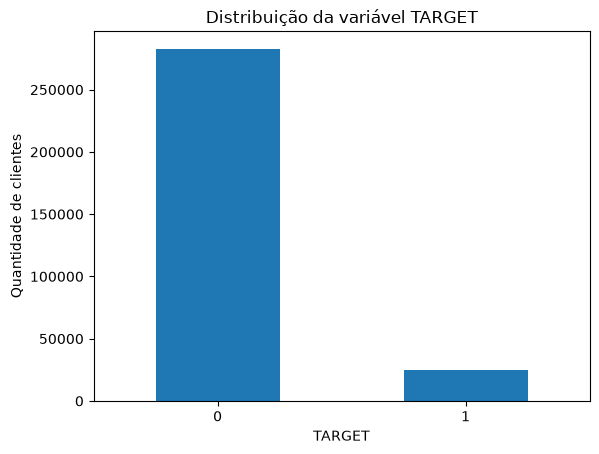

In [7]:
target_freq = (
    df_application["TARGET"]
    .value_counts()
    .rename_axis("TARGET")
    .to_frame("Quantidade")
)

target_freq["Percentual (%)"] = (
    df_application["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_freq["Quantidade"].plot(kind="bar")

plt.title("Distribuição da variável TARGET")
plt.xlabel("TARGET")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)

plt.show()

### Observações do TARGET
* A maioria (~92%) dos clientes pertence à classe 0, indicando que não houve inadimplência.
* Isso caracteriza um problema de classificação desbalanceado, necessitando maior cautela na escolha de métricas de avaliação e aplicação de técnicas para lidar com esse desbalanceamento.

## 1.2 Variáveis Demográficas

Análise das principais características demográficas dos solicitantes: idade, gênero, escolaridade, estado civil, número de filhos, e tipo de renda.

In [8]:
demograficas = [
    "DAYS_BIRTH",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "CNT_CHILDREN",
    "NAME_INCOME_TYPE",
]

df_application[demograficas].head(15)

,DAYS_BIRTH,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,NAME_INCOME_TYPE
0,-9461,M,Secondary / secondary special,Single / not married,0,Working
1,-16765,F,Higher education,Married,0,State servant
2,-19046,M,Secondary / secondary special,Single / not married,0,Working
3,-19005,F,Secondary / secondary special,Civil marriage,0,Working
4,-19932,M,Secondary / secondary special,Single / not married,0,Working
5,-16941,M,Secondary / secondary special,Married,0,State servant
6,-13778,F,Higher education,Married,1,Commercial associate
7,-18850,M,Higher education,Married,0,State servant
8,-20099,F,Secondary / secondary special,Married,0,Pensioner
9,-14469,M,Secondary / secondary special,Single / not married,0,Working


In [9]:
# Verificar nulos 
df_application[demograficas].isna().sum().sort_values(ascending=False)

DAYS_BIRTH             0
CODE_GENDER            0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
CNT_CHILDREN           0
NAME_INCOME_TYPE       0
dtype: int64

In [10]:
# Transformar idade em dias para idade em anos

df_application["IDADE"] = (-df_application["DAYS_BIRTH"] / 365.25).round(1)

### 1.2.1 IDADE

Perguntas a considerar:
1. Qual idade média?
2. Existem idades estranhas que solicitaram empréstimos? 
3. Como que a idade relaciona com o TARGET?

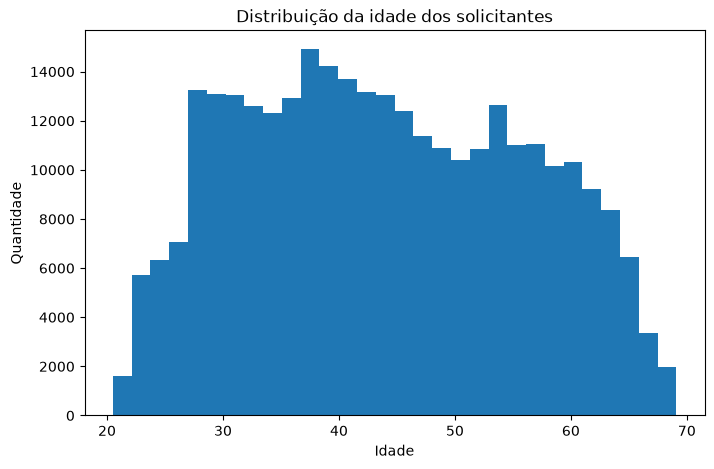

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_application["IDADE"],
    bins=30
)

plt.title("Distribuição da idade dos solicitantes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

In [12]:
df_application.groupby("TARGET")["IDADE"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,44.183969,11.948570,20.5,34.3,43.5,54.2,69.1
1,24825.0,40.752709,11.479462,21.0,31.2,39.1,49.4,68.9


In [13]:
df_application.groupby("TARGET")["IDADE"].median()

TARGET
0    43.5
1    39.1
Name: IDADE, dtype: float64

<Figure size 800x600 with 0 Axes>

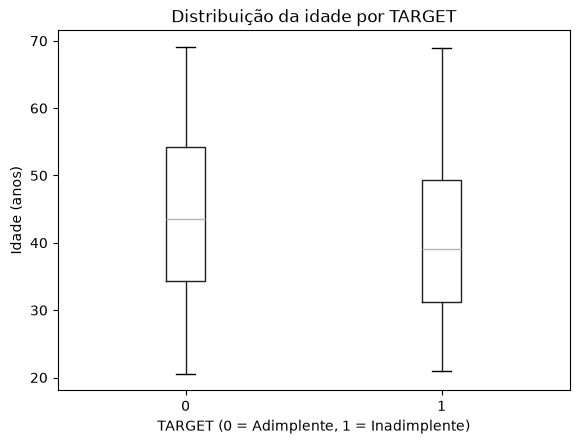

In [14]:
plt.figure(figsize=(8, 6))

df_application.boxplot(
    column="IDADE",
    by="TARGET",
    grid=False
)

plt.title("Distribuição da idade por TARGET")
plt.suptitle("")  # Remove o título automático do pandas
plt.xlabel("TARGET (0 = Adimplente, 1 = Inadimplente)")
plt.ylabel("Idade (anos)")

plt.show()

#### Observações
* Clientes inadimplentes apresentam média e mediana de idade menores. 
* Idade parece ser uma variável relevante para o modelo preditivo.

### 1.2.2 Gênero

Perguntas a considerar:
1. Existe diferença na taxa de inadimplência entre homens e mulheres?

In [20]:
df_application["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [22]:
# Proporcionalidade
df_application["CODE_GENDER"].value_counts(normalize=True) * 100

CODE_GENDER
F      65.834393
M      34.164306
XNA     0.001301
Name: proportion, dtype: float64

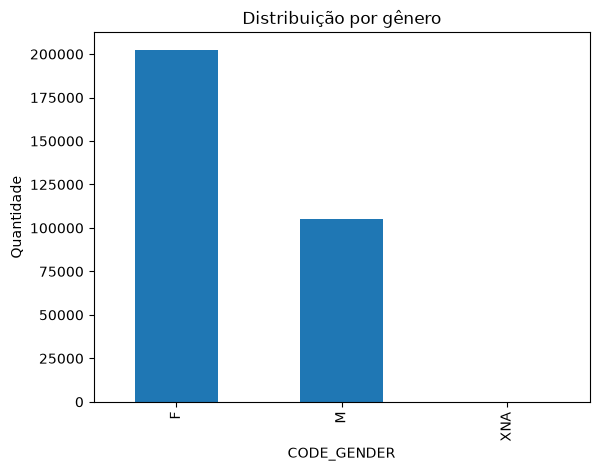

In [ ]:
df_application["CODE_GENDER"].value_counts().plot.bar()

plt.title("Distribuição por gênero")
plt.ylabel("Quantidade")
plt.show()

In [ ]:
genero_target = pd.crosstab(
    df_application["CODE_GENDER"],
    df_application["TARGET"],
    normalize="index"
).round(3)

genero_target

TARGET,0,1
CODE_GENDER,,
F,0.930,0.070
M,0.899,0.101
XNA,1.000,0.000


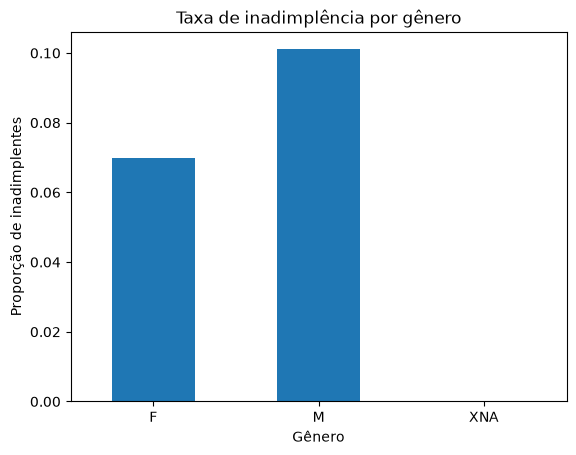

In [26]:
genero_target[1].plot(
    kind="bar"
)

plt.title("Taxa de inadimplência por gênero")
plt.xlabel("Gênero")
plt.ylabel("Proporção de inadimplentes")
plt.xticks(rotation=0)

plt.show()

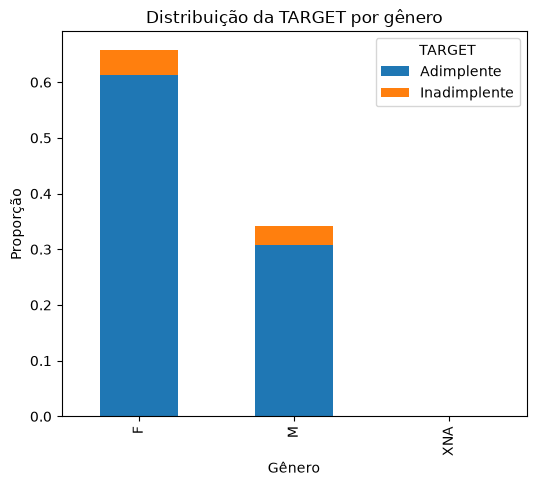

In [32]:
pd.crosstab(
    df_application["CODE_GENDER"],
    df_application["TARGET"],
    normalize="all"
).plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Distribuição da TARGET por gênero")
plt.xlabel("Gênero")
plt.ylabel("Proporção")

plt.legend(
    title="TARGET",
    labels=["Adimplente", "Inadimplente"]
)

plt.show()

#### Observações

* Há somente 4(0.001%) registros com clientes sem declaração de genêro (XNA), possibilidade de removê-los durante a construção da ABT. 
* Mulheres representam 65% dos solicitantes de crédito, mas apresentam uma taxa de inadimplência inferior à observada entre os homens (6.9% entre mulheres e 10.2% entre homens), indicando que a varíavel de gênero ```CODE_GENDER``` pode possuir poder preditivo para o modelo.

## 1.3 Variáveis Financeiras

Aná

In [15]:
financeiras = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

In [16]:
df_application[financeiras].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.937500,402490.781250,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.572266,14493.737305,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.125000,369446.468750,40500.0,238500.0,450000.0,679500.0,4050000.0


## 1.4 Variáveis de Emprego

In [17]:
emprego = [
    "DAYS_EMPLOYED",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

## 1.5 Variáveis de Habitação

In [18]:
habitacao = [
    "FLAG_OWN_REALTY",
    "NAME_HOUSING_TYPE",
]

## 1.6 Scores externos

In [19]:
scores_externos = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]